In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.naive_bayes import GaussianNB

# ----------------------------
# 1. LOAD TRAINING DATA
# ----------------------------
train_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/TrainingData.csv"
df_train = pd.read_csv(train_path)

# Fjern irrelevant features fra TRAINING
irrelevant_cols = ["filnavn", "beta", "snr_db"]
for col in irrelevant_cols:
    if col in df_train.columns:
        df_train = df_train.drop(columns=[col])

# ----------------------------
# 2. FEATURES & TARGET
# ----------------------------
X = df_train.drop(columns=["target"])
y = df_train["target"]

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Klasse mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{class_name} -> {i}")

# ----------------------------
# 3. TRAIN / VALIDATION SPLIT
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# ----------------------------
# 4. NAIVE BAYES MODEL
# ----------------------------
model = GaussianNB()
model.fit(X_train, y_train)

# ----------------------------
# 5. VALIDATION EVALUATION
# ----------------------------
y_val_pred = model.predict(X_val)

print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Validation):")
print(confusion_matrix(y_val, y_val_pred))

# ----------------------------
# 6. LOAD TEST DATA
# ----------------------------
test_path = "https://raw.githubusercontent.com/marcojs253-crypto/P_2/refs/heads/main/Data/ValidationData.csv"
df_test = pd.read_csv(test_path)

# fjern kun filnavn (behold beta og snr_db til analyse)
if "filnavn" in df_test.columns:
    df_test = df_test.drop(columns=["filnavn"])

# Features til modellen
X_test = df_test.drop(columns=["target", "beta", "snr_db"], errors="ignore")

# True labels
y_test_true = label_encoder.transform(df_test["target"])

print("\nUnikke targets i test:", np.unique(y_test_true))
print("Antal prøver pr. klasse:", np.bincount(y_test_true))

# ----------------------------
# 7. TEST PREDICTION
# ----------------------------
y_test_pred = model.predict(X_test)

print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))

Klasse mapping:
BlueNoise -> 0
BrownNoise -> 1
Clean -> 2
PinkNoise -> 3
VioletNoise -> 4
WhiteNoise -> 5

Validation Accuracy: 0.7705314009661836

Classification Report (Validation):
              precision    recall  f1-score   support

   BlueNoise       0.52      0.57      0.54        69
  BrownNoise       0.81      0.88      0.85        69
       Clean       0.86      0.83      0.84        69
   PinkNoise       1.00      0.91      0.95        69
 VioletNoise       0.65      0.70      0.67        69
  WhiteNoise       0.84      0.74      0.78        69

    accuracy                           0.77       414
   macro avg       0.78      0.77      0.77       414
weighted avg       0.78      0.77      0.77       414


Confusion Matrix (Validation):
[[39  0  0  0 20 10]
 [ 0 61  8  0  0  0]
 [ 0 12 57  0  0  0]
 [ 4  0  0 63  2  0]
 [18  2  1  0 48  0]
 [14  0  0  0  4 51]]

Unikke targets i test: [0 1 2 3 4 5]
Antal prøver pr. klasse: [100 100 100 100 100 100]

Test Accuracy: 0.75

Cla

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54783/1313189098.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snr_error = df_noise.groupby("snr_bin")["correct"].mean()


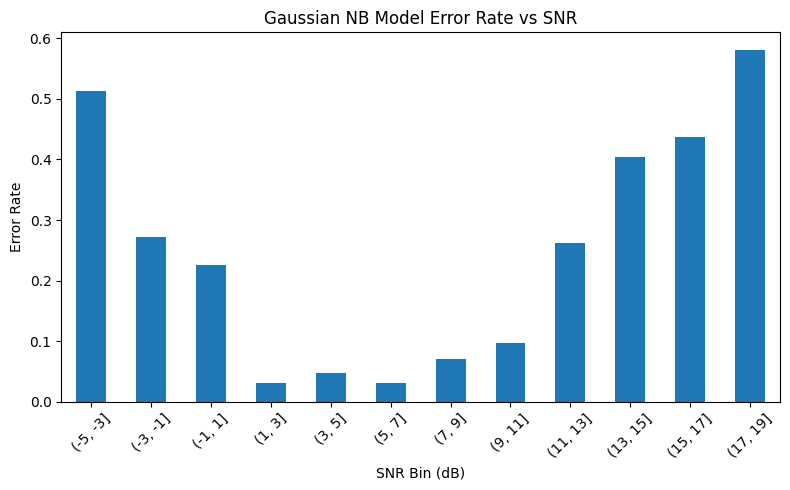

/var/folders/8p/bqxd9lrn4yb0rk196_xwgp780000gn/T/ipykernel_54783/1313189098.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  beta_error = df_noise.groupby("beta_bin")["correct"].mean()


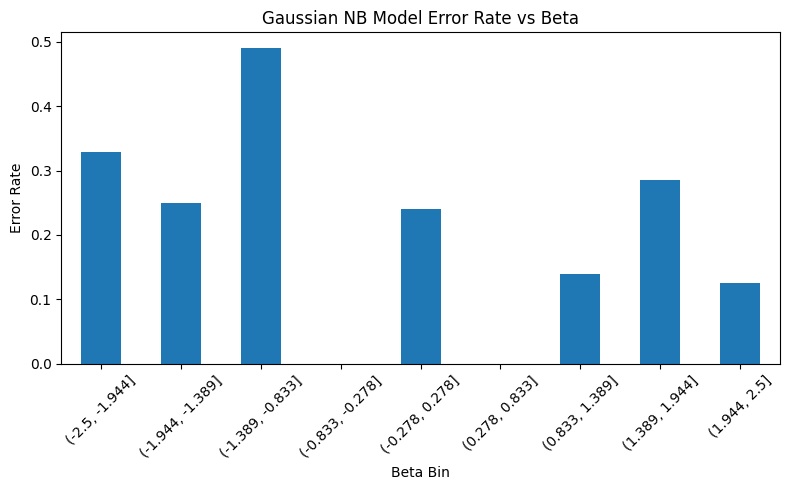


Test Accuracy: 0.75

Classification Report (Test):
              precision    recall  f1-score   support

   BlueNoise       0.50      0.51      0.51       100
  BrownNoise       0.84      0.83      0.83       100
       Clean       0.79      0.85      0.82       100
   PinkNoise       1.00      0.86      0.92       100
 VioletNoise       0.61      0.69      0.65       100
  WhiteNoise       0.81      0.76      0.78       100

    accuracy                           0.75       600
   macro avg       0.76      0.75      0.75       600
weighted avg       0.76      0.75      0.75       600


Confusion Matrix (Test):
[[51  0  0  0 31 18]
 [ 0 83 17  0  0  0]
 [ 0 14 85  0  1  0]
 [ 2  2  0 86 10  0]
 [26  0  5  0 69  0]
 [22  0  0  0  2 76]]

Eksempler på fejl:
   true_label   pred_label  beta  snr_db
0   BlueNoise   WhiteNoise -0.90   -3.87
2   BlueNoise  VioletNoise -0.90   15.67
3   BlueNoise  VioletNoise -0.90   19.65
6   BlueNoise  VioletNoise -0.91   17.86
8   BlueNoise   WhiteNoise 

In [2]:
# ----------------------------
# 8. ERROR ANALYSIS (SNR & BETA)
# ----------------------------

# gem predictions i dataframe
df_analysis = df_test.copy()
df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

# behold kun støj (Clean har NaN)
df_noise = df_analysis.dropna(subset=["snr_db", "beta"]).copy()
# fejlrate pr SNR
snr_bins = np.arange(-5, 21, 2)
df_noise["snr_bin"] = pd.cut(df_noise["snr_db"], bins=snr_bins)

snr_error = df_noise.groupby("snr_bin")["correct"].mean()
snr_error = 1 - snr_error

plt.figure(figsize=(8,5))
snr_error.plot(kind="bar")
plt.title("Gaussian NB Model Error Rate vs SNR")
plt.ylabel("Error Rate")
plt.xlabel("SNR Bin (dB)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# fejlrate pr beta
beta_bins = np.linspace(-2.5, 2.5, 10)
df_noise["beta_bin"] = pd.cut(df_noise["beta"], bins=beta_bins)

beta_error = df_noise.groupby("beta_bin")["correct"].mean()
beta_error = 1 - beta_error

plt.figure(figsize=(8,5))
beta_error.plot(kind="bar")
plt.title("Gaussian NB Model Error Rate vs Beta")
plt.ylabel("Error Rate")
plt.xlabel("Beta Bin")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Lav prediction
y_test_pred = model.predict(X_test)

# Evaluer
print("\nTest Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test_true, y_test_pred, target_names=label_encoder.classes_))
print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test_true, y_test_pred))


# ----------------------------
# ERROR ANALYSIS
# ----------------------------

df_analysis = df_test.copy()

df_analysis["y_true"] = y_test_true
df_analysis["y_pred"] = y_test_pred
df_analysis["correct"] = df_analysis["y_true"] == df_analysis["y_pred"]

df_analysis["true_label"] = label_encoder.inverse_transform(df_analysis["y_true"])
df_analysis["pred_label"] = label_encoder.inverse_transform(df_analysis["y_pred"])

errors = df_analysis[df_analysis["correct"] == False]

print("\nEksempler på fejl:")
print(errors[["true_label","pred_label","beta","snr_db"]].head(20))